In [48]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, BatchNormalization, Dropout
from tensorflow.keras.layers import Input
import os

In [49]:
train_ds = keras.utils.image_dataset_from_directory(
    directory = 'train',
    labels="inferred",
    label_mode="int",                                            
    batch_size=32,
    image_size=(256, 256),
)
validation_ds = keras.utils.image_dataset_from_directory(
    directory = 'test',
    labels="inferred",
    label_mode="int",                                          
    batch_size=32,
    image_size=(256, 256),
)


Found 22501 files belonging to 2 classes.
Found 2508 files belonging to 2 classes.


In [50]:
# convert every image into 0 and 1 form
def process(image, label):
    image = tf.cast(image / 255.0, tf.float32)
    return image, label

train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

In [51]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D,
    BatchNormalization, Dropout,
    GlobalAveragePooling2D, Dense
)

model = Sequential()

# Input
model.add(Input(shape=(256, 256, 3)))

# Block 1
model.add(Conv2D(32, (3,3), activation="relu", padding="same"))
model.add(BatchNormalization())
model.add(MaxPooling2D())

# Block 2
model.add(Conv2D(64, (3,3), activation="relu", padding="same"))
model.add(BatchNormalization())
model.add(MaxPooling2D())

# Block 3
model.add(Conv2D(128, (3,3), activation="relu", padding="same"))
model.add(BatchNormalization())
model.add(MaxPooling2D())

# Block 4 (added improvement)
model.add(Conv2D(256, (3,3), activation="relu", padding="same"))
model.add(BatchNormalization())
model.add(MaxPooling2D())

# 🔥 Better than Flatten
model.add(GlobalAveragePooling2D())

# Fully connected layers
model.add(Dense(128, activation="relu"))
model.add(Dropout(0.5))

model.add(Dense(64, activation="relu"))
model.add(Dropout(0.3))

# Output
model.add(Dense(1, activation="sigmoid"))

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 256, 256, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 431,553 (1.65 MB)

 Trainable params: 430,593 (1.64 MB)

 Non-trainable params: 960 (3.75 KB)

In [52]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [8]:
history = model.fit(train_ds, epochs=10, validation_data=validation_ds)

Epoch 1/10


2026-06-23 02:06:49.649033: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


704/704 ━━━━━━━━━━━━━━━━━━━━ 148s 205ms/step - accuracy: 0.5634 - loss: 0.8071 - val_accuracy: 0.5391 - val_loss: 0.7619
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 143s 202ms/step - accuracy: 0.6265 - loss: 0.6486 - val_accuracy: 0.5171 - val_loss: 0.8955
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 202ms/step - accuracy: 0.6688 - loss: 0.6105 - val_accuracy: 0.6160 - val_loss: 0.6924
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 202ms/step - accuracy: 0.6809 - loss: 0.6019 - val_accuracy: 0.6443 - val_loss: 0.6314
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 202ms/step - accuracy: 0.6961 - loss: 0.5863 - val_accuracy: 0.6695 - val_loss: 0.6103
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 202ms/step - accuracy: 0.7202 - loss: 0.5573 - val_accuracy: 0.5231 - val_loss: 0.9030
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 202ms/step - accuracy: 0.7494 - loss: 0.5235 - val_accuracy: 0.5618 - val_loss: 0.8466
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 202ms/step - accuracy: 0.7816 - loss: 0.48

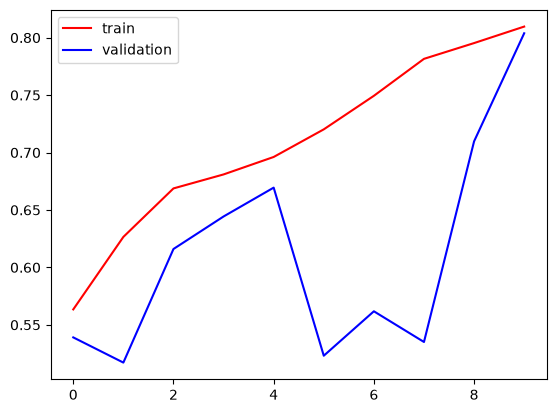

In [53]:

import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], color='red',label='train')
plt.plot(history.history['val_accuracy'], color='blue', label='validation')
plt. legend () 
plt.show()

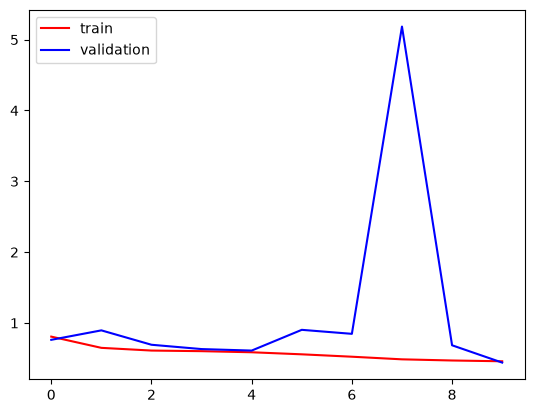

In [54]:
plt.plot(history.history['loss'], color='red', label='train')
plt.plot(history.history['val_loss'], color='blue', label='validation')
plt.legend ()
plt.show()

In [55]:
import cv2
print(cv2.__version__)

4.13.0


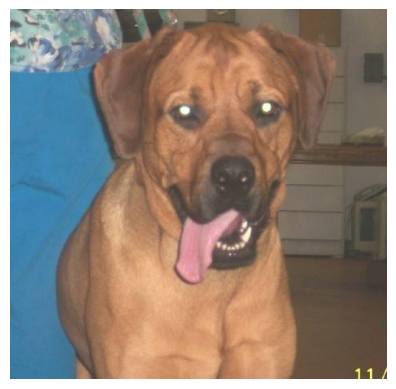

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 322ms/step
Raw Prediction Value: 0.5022776126861572
Prediction: It's a DOG!


In [56]:
image_path = 'train/dog/dog.30.jpg'

if os.path.exists(image_path):
    test_img = cv2.imread(image_path)
    # Convert BGR (OpenCV default) to RGB for correct matplotlib plotting
    test_img_rgb = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)
    plt.imshow(test_img_rgb)
    plt.axis('off')
    plt.show()

    # Preprocess the image to fit model expectations
    test_img_resized = cv2.resize(test_img, (256, 256))
    test_input = test_img_resized.reshape((1, 256, 256, 3))

    # Scale image pixels if the training pipeline scales them
    test_input = test_input / 255.0

    # Prediction
    prediction = model.predict(test_input)
    print(f"Raw Prediction Value: {prediction[0][0]}")

    if prediction[0][0] < 0.5:
        print("Prediction: It's a CAT!")
    else:
        print("Prediction: It's a DOG!")
else:
    print(f"Image not found at {image_path}. Please check your path.")